[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[0.00321575 0.00305854 0.00235033 ... 0.00045732 0.00056663 0.00074372]
 [0.00384924 0.00316075 0.00247522 ... 0.00105797 0.0012306  0.0004607 ]
 [0.00342544 0.0035166  0.00287914 ... 0.00166199 0.00103895 0.00098569]
 ...
 [0.00982675 0.0094929  0.00950322 ... 0.00336615 0.00359917 0.00356811]
 [0.009748   0.00864372 0.0093008  ... 0.00237062 0.00225143 0.00185158]
 [0.00963809 0.00989981 0.00902414 ... 0.00136012 0.0009997  0.00120314]]
False


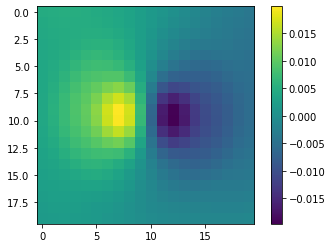

In [1]:
import numpy as np
import matplotlib.pylab as plt
mass_int1 = np.arange(0.0, 4.0, 0.01)

models1 = []
for i in range(len(mass_int1)):
    model = np.load('/big_scratch/sri/for_kevin/cmb_cluster_lensing/kevin_20221019/results/models/models_60arcmin_mass'+str(format(mass_int1[i],".2f"))+'_2.0uKarcmin_1.0arcmin_2500clus_avg10.npy')
    models1.append(model[0])
bg = np.copy(models1[0])
for i in range(len(mass_int1)):
    models1[i] = models1[i]-bg
np.save('../results/models_60arcmin_massint0.0to4.0_massres0.01_2.0uKarcmin_1.0arcmin_2500clus_avg10.npy', models1)
        
    
print(models1[0] == models1[100])
plt.imshow(models1[1][50:70, 50:70])
plt.colorbar()

print(models1[1]-models1[2])
print(np.allclose(models1[3],models1[1]))

In [9]:
print('Importing relevant modules ...')
#%load_ext autoreload 
#%autoreload 2
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
from mpl_toolkits.axes_grid1 import make_axes_locatable
color_arr = ['firebrick', 'deepskyblue', 'forestgreen', 'orange', 'purple', 'black', 'grey', 'lime']
from tqdm import tqdm
import cosmo
import lensing_estimator
import observations as obs
import sims
import stats


###################################################################################################################


print('Defining relevant parameters ...')
nber_clus = 2500
nber_rand = 50000
nber_runs = 10
nx, ny = 120, 120
dx, dy = 0.5, 0.5
map_params = [nx, dx, ny, dy] 
beam_fwhm = 1.0 # arcmin
noiseval_white = 2.0 # uK-arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = obs.beam_power_spectrum(beam_fwhm, l)
nl = obs.instrumental_noise_power_spectrum(noiseval_white, l)
cl_noise = obs.instrumental_noise_power_spectrum(noiseval_white, l, beam_fwhm)
z = 0.7
mass_int1 = np.arange(0.0, 4.0, 0.01)
mass_int_arr = [mass_int1]
input_masses = [1.47e14]


###################################################################################################################


print('Generating models ...')
models1 = np.load('../results/models_60arcmin_massint0.0to4.0_massres0.01_2.0uKarcmin_1.0arcmin_2500clus_avg10.npy')  
models_small1 = []
for model in models1:
    models_small1.append(model[50:70, 50:70])
models1 = np.copy(models_small1)


models_arr = [models1]


print('Generating background stack ..')
stack_bg = np.load('../results/background_60arcmin_2.0uKarcmin_1.0arcmin_50000rand.npy')

print('Generating dipoles, covariances, likelihoods and mass estimates ...')
likelihood_arr = []
comb_likelihood_arr = []
combined_mass_results_file = ''

for i, mass in enumerate(input_masses):
    lnlike_arr_mass = []
    likelihood_arr_mass = []
    for j in range(nber_runs): 
        maps_clus = sims.cmb_mock_data(map_params, l, cl, cluster = [mass, cosmo.concentration_parameter(mass, z, 0.674), z], bl = bl, nber_obs = nber_clus)
        stack_dipole, cutouts_dipole, magnitudes_dipole = lensing_estimator.dipole(maps_clus, stack_bg, map_params, l = l, cl = cl, cl_noise = cl_noise, cutout_size_am = 60)     
        
        stack_dipole_small = stack_dipole[50:70, 50:70] 
        stack_dipole = np.copy(stack_dipole_small)
        
        cutouts_dipole_small = []
        for dipole in cutouts_dipole:
            cutouts_dipole_small.append(dipole[50:70, 50:70])
        cutouts_dipole = np.copy(cutouts_dipole_small)        
        
        covariance_matrix, correlation_matrix = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole, magnitudes_dipole)
        data = stack_dipole, covariance_matrix
        
        lnlike, M_ip, L_ip, median_value, error = stats.run_ml(data, models_arr[i], mass_int_arr[i])
        lnlike_arr_mass.append(lnlike)
        likelihood_arr_mass.append(L_ip)  
        print('\n')
        print('Mass: ', round(mass*1e-14, 0), 'Run', j+1)
        print(median_value, error) 
    
    _, x, comb_likelihood, mass_est_comb, error_comb = stats.combined_likelihood(mass_int_arr[i], lnlike_arr_mass)
        
    likelihood_arr.append(likelihood_arr_mass)
    comb_likelihood_arr.append(comb_likelihood)
    combined_mass_results_file += "{0:11.3f}{1:>1}{2:5.3f}".format(mass_est_comb, "+-", error_comb) + "\n" 
    print('\n')
    print('Mass: ', round(mass*1e-14, 0), 'Combined Results:')
    print(mass_est_comb, error_comb)

Importing relevant modules ...
Defining relevant parameters ...
Generating models ...
Generating background stack ..
Generating dipoles, covariances, likelihoods and mass estimates ...


Mass:  1.0 Run 1
1.4625166993064893 0.008626613112154513


Mass:  1.0 Run 2
1.4549415009395346 0.009378937896200812


Mass:  1.0 Run 3
1.416962015445546 0.009704316473855834


Mass:  1.0 Run 4
1.467444170478923 0.007526479056155222


Mass:  1.0 Run 5
1.4435432482460313 0.007144007441480471


Mass:  1.0 Run 6
1.4265603214038416 0.010148296461847894


Mass:  1.0 Run 7
1.4106978230763358 0.006157462465155472


Mass:  1.0 Run 8
1.4368757823435918 0.0059218998929478905


Mass:  1.0 Run 9
1.4529607332741452 0.010036958331909096


Mass:  1.0 Run 10
1.4478425958988534 0.009390663851166159


Mass:  1.0 Combined Results:
1.440099448567535 0.003670504490974724


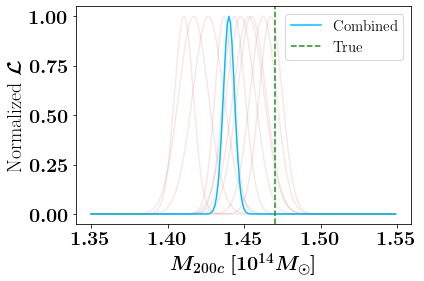

In [17]:
for j in range(nber_runs):
    plt.plot(M_ip[1350:1550], likelihood_arr[0][j][1350:1550], color = color_arr[0], ls='-', alpha = 0.1)
plt.plot(x[1350:1550], comb_likelihood_arr[0][1350:1550], color = color_arr[1], ls = '-', label = 'Combined')
plt.tick_params(labelsize = 20)
plt.axvline(input_masses[i]*1e-14, color = color_arr[2], ls = '--', label = 'True') 
plt.xlabel(r'$M_{200c} \ [10^{14}M_\odot]$', fontsize = 20)
plt.ylabel('Normalized '+r'$\mathcal{L}$', fontsize = 20)
plt.legend(prop={'size': 15})  



In [4]:
print(tzuaefe)

NameError: name 'tzuaefe' is not defined

In [ ]:
%load_ext autoreload 
%autoreload 2
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import sys
sys.path.append('../files')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
from mpl_toolkits.axes_grid1 import make_axes_locatable
color_arr = ['firebrick', 'deepskyblue', 'forestgreen', 'orange', 'purple', 'black', 'grey', 'lime']
from tqdm import tqdm
import cosmo
import lensing_estimator
import observations as obs
import sims
import stats
import tools
import scipy.ndimage
import random
import foregrounds as fg

In [ ]:
from colossus.cosmology import cosmology
from colossus.halo import concentration, mass_defs
cosmology.setCosmology('planck15')

def m500c_m200c(m500cval, zval=0.7, mdefin = '500c', mdefout = '200c'):
    cval = concentration.concentration(m500cval, mdefin, zval)
    retvals = mass_defs.changeMassDefinition(m500cval, cval, zval, mdefin, mdefout , profile='nfw')
    print(retvals[0]*1e-14)

m500c_m200c(1e14)   

In [ ]:
nber_clus = 2500
nber_rand = 50000
nber_runs = 20
map_params = [120, 0.5, 120, 0.5] # nx, dx, ny, dy
beam_fwhm = 1.0 # arcmin
noiseval_white = 2.0 # uK-arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = obs.beam_power_spectrum(beam_fwhm, l)
nl = obs.instrumental_noise_power_spectrum(noiseval_white, l)
cl_noise = obs.instrumental_noise_power_spectrum(noiseval_white, l, beam_fwhm)
z = 0.7
mass_int = np.arange(0.690, 2.25, 0.01)
mass_int[0] = 0
print(mass_int)
M_input = 1.47e14
nx = 120
ny = 120
dx = 0.5
dy = 0.5

In [ ]:
#%%script false --no-raise-error
#ksz_cutouts = np.load('../sims/ksz_cutouts_1.0beam.npy') 
nx_cutout, ny_cutout = ksz_cutouts[0].shape[0], ksz_cutouts[0].shape[1]
s, e = int((nx-nx_cutout)/2), int((ny+ny_cutout)/2)

ksz_arr_true = []
cnt=0
for i in range(nber_runs):
    ksz_arr_current = []
    for j in range(nber_clus): 
        rand_sel = random.randint(0, len(ksz_cutouts)-1)
        cluster_corr_cutout = ksz_cutouts[rand_sel]  #ksz_cutouts[j+cnt]   
        ksz_arr_current.append(cluster_corr_cutout)
    cnt+=2500
    ksz_arr_true.append(ksz_arr_current)

In [ ]:
#%%script false --no-raise-error
plt.imshow(np.mean(ksz_arr_true[-1], axis = 0))
plt.colorbar()

In [ ]:
#%%script false --no-raise-error
#tsz_cutouts = np.load('../sims/tsz_cutouts_1.0beam.npy') 
cnt=0
tsz_arr_true = []
for i in range(nber_runs):  
    tsz_arr_true_temp = []
    for j in range(nber_clus):
        rand_sel = random.randint(0, len(tsz_cutouts)-1)
        cluster_corr_cutout = tsz_cutouts[rand_sel] #tsz_cutouts[j+cnt] 
        tsz_arr_true_temp.append(cluster_corr_cutout)
    cnt+=2500
    tsz_arr_true.append(tsz_arr_true_temp)

In [ ]:
#%%script false --no-raise-error
plt.imshow(np.mean(tsz_arr_true[-1], axis = 0))
plt.colorbar()

In [ ]:
%%script false --no-raise-error
models = lensing_estimator.models(nber_clus, map_params, l, cl, mass_int, z, bl = bl, cl_noise = cl_noise, average = 1, cutout_size_am = 60)
np.save('../results/models_60arcmin_massint0.75to2.25_massres0.01_2.0uKarcmin_1.0arcmin_2500clus.npy', models)

In [ ]:
models = np.load('../results/models_60arcmin_massint0.75to2.25_massres0.01_2.0uKarcmin_1.0arcmin_2500clus.npy')  
models_small = []
for model in models:
    models_small.append(model[50:70, 50:70])
models = np.copy(models_small)

In [ ]:
plt.imshow(models[150])
plt.colorbar()

In [ ]:
%%script false --no-raise-error
maps_rand = sims.cmb_mock_data(map_params, l, cl,  bl = bl, nl = nl, nber_obs = nber_rand)
stack_bg, _, _ = lensing_estimator.background(maps_rand, map_params, l = l, cl = cl, cl_noise = cl_noise, cutout_size_am = 60) 
del maps_rand
np.save('../results/background_60arcmin_2.0uKarcmin_1.0arcmin_50000rand.npy', stack_bg)

In [ ]:
stack_bg = np.load('../results/background_60arcmin_2.0uKarcmin_1.0arcmin_50000rand.npy')

plt.imshow(stack_bg)
plt.colorbar()

In [ ]:
lnlike_arr_baseline = []
lnlike_arr_ksz = []
lnlike_arr_tsz = []
lnlike_arr_tsz_corrected = []
lnlike_arr_tsz_corrected_fit = []
lnlike_arr_ksz_tsz_corrected = []
lnlike_arr_ksz_tsz_corrected_fit = []

likelihood_arr_baseline = []
likelihood_arr_ksz = []
likelihood_arr_tsz = []
likelihood_arr_tsz_corrected = []
likelihood_arr_tsz_corrected_fit = []
likelihood_arr_ksz_tsz_corrected = []
likelihood_arr_ksz_tsz_corrected_fit = []

mass_arr_baseline = []
mass_arr_ksz = []
mass_arr_tsz = []
mass_arr_tsz_corrected = []
mass_arr_tsz_corrected_fit = []
mass_arr_ksz_tsz_corrected = []
mass_arr_ksz_tsz_corrected_fit = []

for i in range(nber_runs):    

    maps_clus = sims.cmb_mock_data(map_params, l, cl, cluster = [M_input, cosmo.concentration_parameter(M_input, z, 0.674), z], bl = bl, nber_obs = nber_clus)

    maps_clus_arr_baseline, maps_clus_arr_ksz, maps_clus_arr_tsz  = np.copy(maps_clus), np.copy(maps_clus), np.copy(maps_clus)
    maps_clus_arr_ksz_tsz = np.copy(maps_clus)
    
    
    #%%script false --no-raise-error
    fname = '/big_scratch/sri/for_kevin/mdpl2_cutouts_for_tszksz_clus_detection_M8.5e+13to1.15e+14_z0.67to0.75_32995haloes_boxsize121.0am_dx0.5am_beam1.0am.npz'
    cutouts_dic = np.load(fname, allow_pickle = 1, encoding= 'latin1')['arr_0'].item()
    mass_z_key = list(cutouts_dic.keys())[0]
    cutouts = cutouts_dic[mass_z_key]
    #scale_fac = fg.compton_y_to_delta_Tcmb(freq = 150, uK = True)
    tsz_cutouts, ksz_cutouts, ksz_tsz_cutouts = [], [], []
    keys = []
    for kcntr, keyname in enumerate( cutouts ):
        #if keyname[-1] >= 1.7 and keyname[-1] <= 1.9:
        keys.append(keyname[-1])
        ksz_cutout = cutouts[keyname]['ksz']
        ksz_cutouts.append(ksz_cutout[61:181, 61:181])
        tsz_cutout = cutouts[keyname]['y']#*scale_fac
        tsz_cutouts.append(tsz_cutout[61:181, 61:181])
    #np.save('../sims/ksz_cutouts_2e14_1.0beam.npy', ksz_cutouts) 
    #np.save('../sims/tsz_cutouts_2e14_1.0beam.npy', tsz_cutouts)
    plt.hist(keys, bins=10)    
    
    
    
    
    for j in range(nber_clus):           
        maps_clus_arr_ksz[j][s:e, s:e] = maps_clus_arr_ksz[j][s:e, s:e]+ksz_arr_true[i][j]           
        maps_clus_arr_tsz[j][s:e, s:e] = maps_clus_arr_tsz[j][s:e, s:e]+tsz_arr_true[i][j]         
        maps_clus_arr_ksz_tsz[j][s:e, s:e] = maps_clus_arr_ksz_tsz[j][s:e, s:e]+ksz_arr_true[i][j]+tsz_arr_true[i][j]
    
    for j in range(nber_clus):
        white_noise_map = tools.make_gaussian_realization(l, nl, map_params) 
        maps_clus_arr_baseline[j] = maps_clus_arr_baseline[j] + white_noise_map
        maps_clus_arr_ksz[j] = maps_clus_arr_ksz[j] + white_noise_map
        maps_clus_arr_tsz[j] = maps_clus_arr_tsz[j] + white_noise_map
        maps_clus_arr_ksz_tsz[j] = maps_clus_arr_ksz_tsz[j] + white_noise_map
    
    stack_dipole_baseline, cutouts_dipole_baseline, magnitudes_dipole_baseline = lensing_estimator.dipole(maps_clus_arr_baseline, stack_bg, map_params, l = l, cl = cl, cl_noise = cl_noise, cutout_size_am = 60)     
    
    stack_dipole_baseline_small = stack_dipole_baseline[50:70, 50:70]
    stack_dipole_baseline = np.copy(stack_dipole_baseline_small)
    cutouts_dipole_baseline_small = []
    for dipole in cutouts_dipole_baseline:
        cutouts_dipole_baseline_small.append(dipole[50:70, 50:70])
    cutouts_dipole_baseline = np.copy(cutouts_dipole_baseline_small)
    
    
    stack_dipole_ksz, cutouts_dipole_ksz, magnitudes_dipole_ksz = lensing_estimator.dipole(maps_clus_arr_ksz, stack_bg, map_params, l = l, cl = cl, cl_noise = cl_noise, cutout_size_am = 60) 
    
    stack_dipole_ksz_small = stack_dipole_ksz[50:70, 50:70]
    stack_dipole_ksz = np.copy(stack_dipole_ksz_small)
    cutouts_dipole_ksz_small = []
    for dipole in cutouts_dipole_ksz:
        cutouts_dipole_ksz_small.append(dipole[50:70, 50:70])
    cutouts_dipole_ksz = np.copy(cutouts_dipole_ksz_small)    
    
    stack_dipole_tsz, cutouts_dipole_tsz, magnitudes_dipole_tsz = lensing_estimator.dipole(maps_clus_arr_tsz, stack_bg, map_params, l = l, cl = cl, cl_noise = cl_noise, tsz_weights = None, cutout_size_am = 60) 
    
    stack_dipole_tsz_small = stack_dipole_tsz[50:70, 50:70]
    stack_dipole_tsz = np.copy(stack_dipole_tsz_small)
    cutouts_dipole_tsz_small = []
    for dipole in cutouts_dipole_tsz:
        cutouts_dipole_tsz_small.append(dipole[50:70, 50:70])
    cutouts_dipole_tsz = np.copy(cutouts_dipole_tsz_small)    
    
    stack_dipole_tsz1, stack_dipole_tsz2, cutouts_dipole_tsz1, cutouts_dipole_tsz2, magnitudes_dipole_tsz1, magnitudes_dipole_tsz2, stack_tsz_tsz1, stack_tsz_tsz2 = lensing_estimator.dipole(maps_clus_arr_tsz, stack_bg, map_params, l = l, cl = cl, cl_noise = cl_noise, correct_for_tsz = True, tsz_weights = True, cutout_size_am = 60)  
    
    stack_dipole_tsz1_small = stack_dipole_tsz1[50:70, 50:70]
    stack_dipole_tsz1 = np.copy(stack_dipole_tsz1_small) 
    cutouts_dipole_tsz1_small = []
    for dipole in cutouts_dipole_tsz1:
        cutouts_dipole_tsz1_small.append(dipole[50:70, 50:70])
    cutouts_dipole_tsz1 = np.copy(cutouts_dipole_tsz1_small)        
 

    stack_dipole_ksz_tsz1, stack_dipole_ksz_tsz2, cutouts_dipole_ksz_tsz1, cutouts_dipole_ksz_tsz2, magnitudes_dipole_ksz_tsz1, magnitudes_dipole_ksz_tsz2, stack_tsz_ksz_tsz1, stack_tsz_ksz_tsz2 = lensing_estimator.dipole(maps_clus_arr_ksz_tsz, stack_bg, map_params, l = l, cl = cl, cl_noise = cl_noise, correct_for_tsz = True, tsz_weights = True, cutout_size_am = 60)  
    
    stack_dipole_ksz_tsz1_small = stack_dipole_ksz_tsz1[50:70, 50:70]
    stack_dipole_ksz_tsz1 = np.copy(stack_dipole_ksz_tsz1_small) 
    cutouts_dipole_ksz_tsz1_small = []
    for dipole in cutouts_dipole_ksz_tsz1:
        cutouts_dipole_ksz_tsz1_small.append(dipole[50:70, 50:70])
    cutouts_dipole_ksz_tsz1 = np.copy(cutouts_dipole_ksz_tsz1_small) 

    covariance_matrix_baseline, correlation_matrix_baseline = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_baseline, magnitudes_dipole_baseline)
    covariance_matrix_ksz, correlation_matrix_ksz = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_ksz, magnitudes_dipole_ksz)
    covariance_matrix_tsz, correlation_matrix_tsz = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_tsz, magnitudes_dipole_tsz)
    covariance_matrix_tsz1, correlation_matrix_tsz1 = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_tsz1, magnitudes_dipole_tsz1)
    covariance_matrix_tsz2, correlation_matrix_tsz2 = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_tsz2, magnitudes_dipole_tsz2)
    covariance_matrix_ksz_tsz1, correlation_matrix_ksz_tsz1 = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_ksz_tsz1, magnitudes_dipole_ksz_tsz1)
    covariance_matrix_ksz_tsz2, correlation_matrix_ksz_tsz2 = lensing_estimator.covariance_and_correlation_matrix(cutouts_dipole_ksz_tsz2, magnitudes_dipole_ksz_tsz2)
  
    data_baseline = stack_dipole_baseline, covariance_matrix_baseline
    data_ksz = stack_dipole_ksz, covariance_matrix_ksz
    data_tsz = stack_dipole_tsz, covariance_matrix_tsz
    data_tsz1 = stack_dipole_tsz1, covariance_matrix_tsz1
    data_tsz2 = stack_dipole_tsz2, covariance_matrix_tsz2
    data_ksz_tsz1 = stack_dipole_ksz_tsz1, covariance_matrix_ksz_tsz1
    data_ksz_tsz2 = stack_dipole_ksz_tsz2, covariance_matrix_ksz_tsz2

    lnlike_baseline, M_ip_baseline, L_ip_baseline, median_value_baseline, error_baseline = stats.run_ml(data_baseline, models, mass_int)
    lnlike_ksz, M_ip_ksz, L_ip_ksz, median_value_ksz, error_ksz = stats.run_ml(data_ksz, models, mass_int)
    lnlike_tsz, M_ip_tsz, L_ip_tsz, median_value_tsz, error_tsz = stats.run_ml(data_tsz, models, mass_int)
    lnlike_tsz1, M_ip_tsz1, L_ip_tsz1, median_value_tsz1, error_tsz1 = stats.run_ml(data_tsz1, models, mass_int)
    lnlike_tsz2, M_ip_tsz2, L_ip_tsz2, median_value_tsz2, error_tsz2 = stats.run_ml(data_tsz2, models, mass_int)
    lnlike_ksz_tsz1, M_ip_ksz_tsz1, L_ip_ksz_tsz1, median_value_ksz_tsz1, error_ksz_tsz1 = stats.run_ml(data_ksz_tsz1, models, mass_int)
    lnlike_ksz_tsz2, M_ip_ksz_tsz2, L_ip_ksz_tsz2, median_value_ksz_tsz2, error_ksz_tsz2 = stats.run_ml(data_ksz_tsz2, models, mass_int)
    
    mass_arr_baseline.append(median_value_baseline)
    mass_arr_ksz.append(median_value_ksz)
    mass_arr_tsz.append(median_value_tsz)
    mass_arr_tsz_corrected.append(median_value_tsz1)
    mass_arr_tsz_corrected_fit.append(median_value_tsz2) 
    mass_arr_ksz_tsz_corrected.append(median_value_ksz_tsz1) 
    mass_arr_ksz_tsz_corrected_fit.append(median_value_ksz_tsz2) 
    
    lnlike_arr_baseline.append(lnlike_baseline)
    lnlike_arr_ksz.append(lnlike_ksz)
    lnlike_arr_tsz.append(lnlike_tsz)
    lnlike_arr_tsz_corrected.append(lnlike_tsz1)
    lnlike_arr_tsz_corrected_fit.append(lnlike_tsz2)
    lnlike_arr_ksz_tsz_corrected.append(lnlike_ksz_tsz1)
    lnlike_arr_ksz_tsz_corrected_fit.append(lnlike_ksz_tsz2)
    
    likelihood_arr_baseline.append(L_ip_baseline)
    likelihood_arr_ksz.append(L_ip_ksz)
    likelihood_arr_tsz.append(L_ip_tsz)
    likelihood_arr_tsz_corrected.append(L_ip_tsz1)
    likelihood_arr_tsz_corrected_fit.append(L_ip_tsz2)   
    likelihood_arr_ksz_tsz_corrected.append(L_ip_ksz_tsz1)
    likelihood_arr_ksz_tsz_corrected_fit.append(L_ip_ksz_tsz2)   
    
    print('Run', i+1)
    print(median_value_baseline, error_baseline)
    print(median_value_ksz, error_ksz)
    print(median_value_tsz, error_tsz)
    print(median_value_tsz1, error_tsz1)
    print(median_value_tsz2, error_tsz2)
    print(median_value_ksz_tsz1, error_ksz_tsz1)
    print(median_value_ksz_tsz2, error_ksz_tsz2)
    
_, x, comb_likelihood_baseline, mass_est_comb_baseline, error_comb_baseline = stats.combined_likelihood(mass_int, lnlike_arr_baseline)
_, x, comb_likelihood_ksz, mass_est_comb_ksz, error_comb_ksz = stats.combined_likelihood(mass_int, lnlike_arr_ksz)
_, x, comb_likelihood_tsz, mass_est_comb_tsz, error_comb_tsz = stats.combined_likelihood(mass_int, lnlike_arr_tsz)
_, x, comb_likelihood_tsz_corrected, mass_est_comb_tsz_corrected, error_comb_tsz_corrected = stats.combined_likelihood(mass_int, lnlike_arr_tsz_corrected)
_, x, comb_likelihood_tsz_corrected_fit, mass_est_comb_tsz_corrected_fit, error_comb_tsz_corrected_fit = stats.combined_likelihood(mass_int, lnlike_arr_tsz_corrected_fit)
_, x, comb_likelihood_ksz_tsz_corrected, mass_est_comb_ksz_tsz_corrected, error_comb_ksz_tsz_corrected = stats.combined_likelihood(mass_int, lnlike_arr_ksz_tsz_corrected)
_, x, comb_likelihood_ksz_tsz_corrected_fit, mass_est_comb_ksz_tsz_corrected_fit, error_comb_ksz_tsz_corrected_fit = stats.combined_likelihood(mass_int, lnlike_arr_ksz_tsz_corrected_fit)

likelihood_arr = [likelihood_arr_baseline, likelihood_arr_ksz, likelihood_arr_tsz, 
                  likelihood_arr_tsz_corrected, likelihood_arr_tsz_corrected_fit,
                  likelihood_arr_ksz_tsz_corrected, likelihood_arr_ksz_tsz_corrected_fit]

mass_results_arr = [mass_arr_baseline, mass_arr_ksz, mass_arr_tsz, mass_arr_tsz_corrected_fit,
                    mass_arr_ksz_tsz_corrected_fit]

comb_likelihood_arr = [comb_likelihood_baseline, comb_likelihood_ksz, comb_likelihood_tsz, 
                       comb_likelihood_tsz_corrected, comb_likelihood_tsz_corrected_fit,
                       comb_likelihood_ksz_tsz_corrected, comb_likelihood_ksz_tsz_corrected_fit]

comb_mass_arr = [mass_est_comb_baseline, mass_est_comb_ksz, mass_est_comb_tsz, 
                 mass_est_comb_tsz_corrected_fit, mass_est_comb_ksz_tsz_corrected_fit]
comb_error_arr = [error_comb_baseline, error_comb_ksz, error_comb_tsz,
                  error_comb_tsz_corrected_fit, error_comb_ksz_tsz_corrected_fit]


print('\n')
print('Combined Results:')
print(mass_est_comb_baseline, error_comb_baseline)
print(mass_est_comb_ksz, error_comb_ksz)
print(mass_est_comb_tsz, error_comb_tsz)
print(mass_est_comb_tsz_corrected, error_comb_tsz_corrected)
print(mass_est_comb_tsz_corrected_fit, error_comb_tsz_corrected_fit)
print(mass_est_comb_ksz_tsz_corrected, error_comb_ksz_tsz_corrected)
print(mass_est_comb_ksz_tsz_corrected_fit, error_comb_ksz_tsz_corrected_fit)

combined_mass_results_file = ''
for i in range(len(comb_mass_arr)):
    combined_mass_results_file += "{0:11.3f}{1:>1}{2:5.3f}".format(comb_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  

file = open('../results/combined_mass_results_foreground_bias.txt',"w")
file.write(combined_mass_results_file)
file.close()

In [ ]:
plt.imshow(covariance_matrix_baseline)
plt.colorbar()
plt.subplots()
plt.imshow(covariance_matrix_ksz)
plt.colorbar()
plt.subplots()
plt.imshow(covariance_matrix_tsz)
plt.colorbar()
plt.subplots()
plt.imshow(covariance_matrix_tsz1)
plt.colorbar()
plt.subplots()
plt.imshow(covariance_matrix_tsz2)
plt.colorbar()
plt.subplots()
plt.imshow(covariance_matrix_ksz_tsz1)
plt.colorbar()
plt.subplots()
plt.imshow(covariance_matrix_ksz_tsz2)
plt.colorbar()

In [ ]:
plt.imshow(stack_dipole_baseline)
plt.colorbar()
plt.subplots()
plt.imshow(stack_dipole_ksz)
plt.colorbar()
plt.subplots()
plt.imshow(stack_dipole_tsz)
plt.colorbar()
plt.subplots()
plt.imshow(stack_dipole_tsz1)
plt.colorbar()
plt.subplots()
plt.imshow(stack_tsz_tsz1[50:70, 50:70])
plt.colorbar()
plt.subplots()
plt.imshow(stack_dipole_tsz2)
plt.colorbar()
plt.subplots()
plt.imshow(stack_tsz_tsz2)
plt.colorbar()
plt.subplots()
plt.imshow(stack_dipole_ksz_tsz1)
plt.colorbar()
plt.subplots()
plt.imshow(stack_tsz_ksz_tsz1[50:70, 50:70])
plt.colorbar()
plt.subplots()
plt.imshow(stack_dipole_ksz_tsz2)
plt.colorbar()
plt.subplots()
plt.imshow(stack_tsz_ksz_tsz2)
plt.colorbar()

In [ ]:
title_arr = ['baseline', '+ ksz', '+ tsz', 'tsz corrected', 'tsz corrected (fit)', r'+ kSZ $\&$ tSZ corrected', r'+ kSZ $\&$ tSZ corrected (fit)']

fig, axarr = plt.subplots(7, 1, figsize = (15, 30))

for i in range(len(axarr)):
    axarr[i].set_title(title_arr[i], size = 20)
    for j in range(nber_runs):
        axarr[i].plot(M_ip_baseline[500:3000], likelihood_arr[i][j][500:3000], color = 'red', alpha = 0.2)
    axarr[i].axvline(1.47, color = 'green')
    axarr[i].plot(x[500:3000], comb_likelihood_arr[i][500:3000], color = 'black')

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
xvals = [0.05, 0.05, 0.05, 0.05, 0.05]
yvals = [0.15, 0.35, 0.55, 0.75, 0.95]
titles_arr = ['baseline', '+ kSZ', '+ tSZ', '+ tSZ corrected', r'+ kSZ $\&$ tSZ corrected']
ax.set_ylim(0.,1)
markers = ['o', '^', 'd', 'v', 'D']
ax.axvline(0, color = 'black', ls = '-')
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(labelsize = 22)
ax.axes.yaxis.set_ticks([])


ax.set_xlabel(r'$M_{\rm fit}-M_{\rm true}$', fontsize = 28)
for i in range(len(xvals)):
    ax.text(xvals[i], yvals[i], titles_arr[i], fontsize = 22)
    
#for i in range(len(mass_results_arr)):
    #yval = [yvals[i] for j in range(len(mass_results_arr[i]))]
    #ax.plot(np.asarray(mass_results_arr[i])-1.47, yval, color = color_arr[i], marker = markers[i], markersize = 12, ls = '', alpha = 0.25)
for i in range(len(comb_mass_arr)):  
    ax.errorbar((comb_mass_arr[i]-1.47)/1.47, yvals[i], xerr = comb_error_arr[i]/1.47, elinewidth = 4, color = color_arr[i],  marker = markers[i], markersize = 12, ls = '', capsize=5, capthick=3)

plt.savefig('../results/foreground_bias.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)